# Normalised linear stability spectra

## Packages

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np

from pathlib import PosixPath
user_home_path = PosixPath('~/')
user_home_path_full = user_home_path.expanduser()

import sys
sys.path.append("../")

import autolib
import dynplot
import Optimisation.opt as opt
import parameters
_, L, m, c = parameters.Parameters()


l_width = 2.5
colorY = "blue"
colorvY = "dodgerblue"  #cornflowerblue
colorphi = "red"  #"royalblue"
colorvphi = "tomato"  #coral
colorReal = (0.7, 0, 0)
colorImag = 'blue'
colorY2 = "blue"
colorvY2 = "red"  #cornflowerblue
colorphi2 = "black"  #"royalblue"
colorvphi2 = "lightgreen"  #coral

## Load the chosen grating

In [15]:
runID = "Fasymp20_cutoff"
I = 5e8
final_speed = 20.
speed_range = np.array([0.,final_speed])
wavelength_range = np.array([1., 1./parameters.D1_ND([0.2,0.])])
num_points = 200
normalise = False  # Normalise the Jacobian

# Calculate the linear stability information for the chosen grating whose eigenvectors 
# you wish to plot alongside the dynamics
num_cores = 200
maxtime = 1440
output_opt_idx = 18

# Define the file paths for the optimisation results
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
fname_preamble = common_path / custom_folder_path

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

_, _, grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=output_opt_idx)
grating.npa = autolib.AutoLib('torch', device='cpu', precision='double')  # twobox.npa isn't saved during optimisation, must set manually
print(grating.params)

I = 5e8*grating.gaussian_width/L*np.sqrt(np.pi/2)

betas = np.linspace(0,final_speed/100, num_points)
wavelengths = np.linspace(1., 1./parameters.D1_ND([0.2,0.]), num_points)

# Save path
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Dynamics"
custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
fname_preamble = common_path / custom_folder_path
fname_preamble.mkdir(parents=True, exist_ok=True)

Total function evaluations: 578867
Average function evaluations per core: 2894
[tensor(2.5007, dtype=torch.float64), tensor(0.2956, dtype=torch.float64), tensor(0.0195, dtype=torch.float64), tensor(0.3054, dtype=torch.float64), tensor(2.8439, dtype=torch.float64), tensor(3.9347, dtype=torch.float64), tensor(0.0226, dtype=torch.float64), tensor(11.8962, dtype=torch.float64)]


## Calculate lsa quantities

In [16]:
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=normalise)

## Eigenvalues and eigenvectors

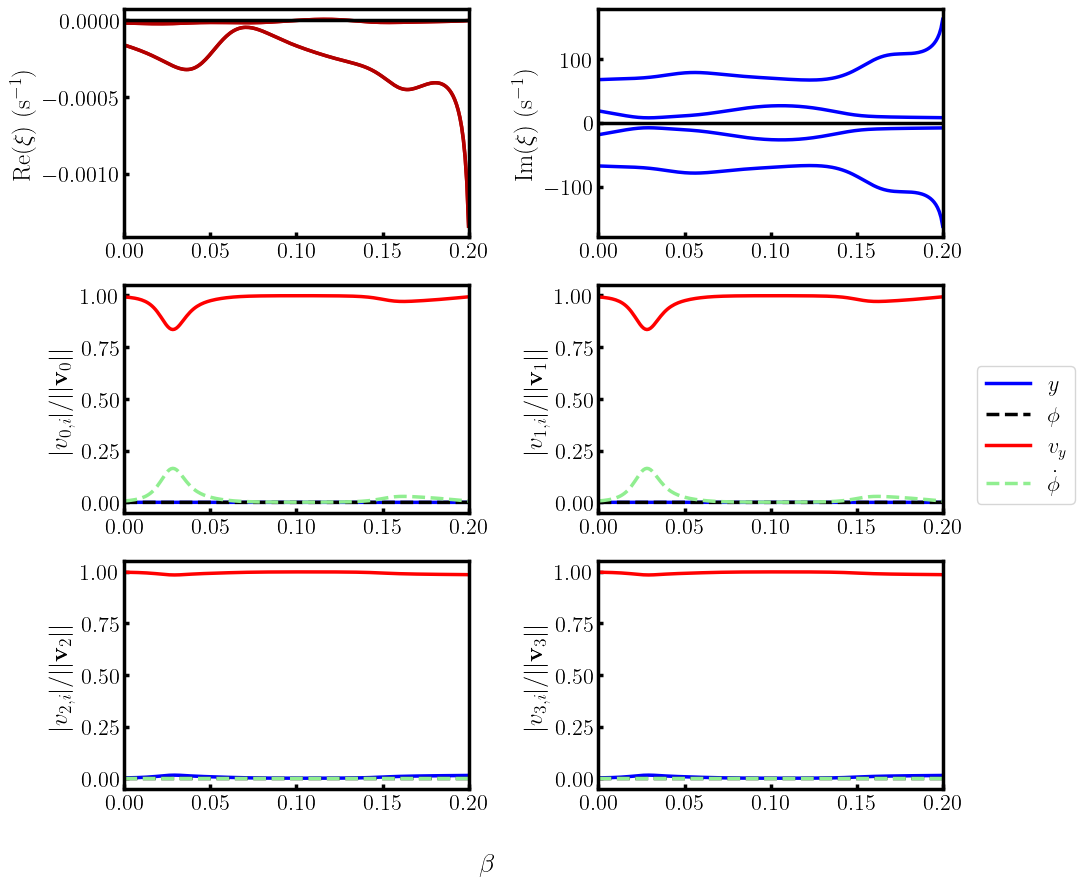

In [17]:
# Plot eigenvectors separately
log_axis = False
eigvec_fig, axs = plt.subplots(3,2, figsize=(10,9))

axs_flat = axs.flatten()
axs_flat[0].plot(betas, real_eigvals, color=colorReal, linewidth=l_width)
axs_flat[1].plot(betas, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(betas[0],betas[-1]))
axs_flat[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)" if not normalise else r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)" if not normalise else r"$\Im(\bar{\xi})$", show_zero_line=True)

axs_flat = axs_flat[2:]
# axs_flat[1], axs_flat[2] = axs_flat[2], axs_flat[1]  # switch so that degenerate eigvec magnitudes are shown in columns
for eigvec_idx, ax in enumerate(axs_flat):
    ax.plot(betas, eigvec_moduli[:,0,eigvec_idx], label=r"$y$" if not normalise else r"$\bar{y}$", color=colorY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,1,eigvec_idx], label=r"$\phi$", color=colorphi2, linewidth=l_width, linestyle="--")
    ax.plot(betas, eigvec_moduli[:,2,eigvec_idx], label=r"$v_y$" if not normalise else r"$\bar{v}_y$", color=colorvY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,3,eigvec_idx], label=r"$\dot{\phi}$" if not normalise else r"$\bar{\dot{\phi}}$", color=colorvphi2, linewidth=l_width, linestyle="--")

    if log_axis:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(1e-9,1e1))
        ax.set_yscale('log')
    else:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(-0.05,1.05))
    nd_ylabel = rf"$|v_{{{eigvec_idx},i}}|/||\mathbf{{v}}_{{{eigvec_idx}}}||$" if not normalise else rf"$|\bar{{v}}_{{{eigvec_idx},i}}|/||\bar{{\mathbf{{v}}}}_{{{eigvec_idx}}}||$"
    ax = dynplot.show_standard_axes(ax, None, xlabel=None, ylabel=nd_ylabel, show_zero_line=False)
    

eigvec_fig.supxlabel(r"$\beta$")
handles, labels = ax.get_legend_handles_labels()
leg = eigvec_fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1,0.5))

# ftype = ".pdf"
# save_fname = str(fname_preamble) + f"/{runID}_eigen_normalise{normalise}" + ftype
# eigvec_fig.savefig(save_fname, bbox_inches="tight")

## Quality factor

In [ ]:
q_fig, q_ax = plt.subplots(1, figsize=(5,4))
q_ax.plot(betas, real_eigvals/imag_eigvals, color="green", linewidth=l_width)
ylabel = r"$\Re(\xi)/\Im(\xi)$" if not normalise else r"$\Re(\bar{\xi})/\Im(\bar{\xi})$"
dynplot.show_standard_axes(q_ax, None, xlabel=r"$\beta$", ylabel=ylabel, show_zero_line=True)

save_fname = str(fname_preamble) + f"/{runID}_quality_factor_normalise{normalise}" + ftype
q_fig.savefig(save_fname, bbox_inches="tight")

## Jacobian terms spectra

### All terms

Grouped by acceleration or angular acceleration

Can choose to calculate the Jacobian terms using Qpr derivatives or directly from the diffraction derivatives.

In [18]:
# Jacobians terms directly from Qpr derivatives
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

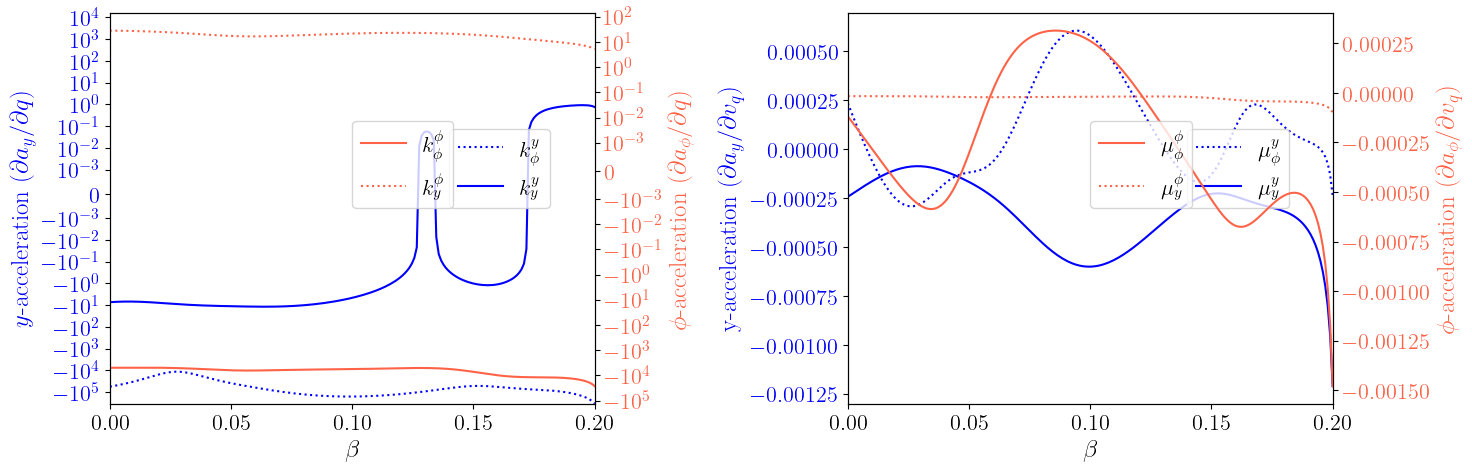

In [19]:
################
# Restoring terms
stiff_fig,(ax, ax2) = plt.subplots(1,2,figsize=(15,5))


ax.plot(betas, kyphi,  label=r"$k^y_\phi$",color=colorY,linestyle="dotted")
ax.plot(betas, kyy,    label=r"$k^y_y$",color=colorY)

ax.set_xlabel(r"$\beta$")
ay_coord_label = r"Norm. $y$-acceleration ($\partial a_y/\partial q$)" if normalise else r"$y$-acceleration ($\partial a_y/\partial q$)"
ax.set_ylabel(ay_coord_label,color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

# ax.hlines(0,0,5,"k","dashed",alpha=0.2)
t = ax.get_ylim()
# ax.axhspan(0,t[1],color='black',alpha=0.2)

ax1 = ax.twinx()
ax1.plot(betas, kphiy,  label=r"$k^\phi_y$",color=colorvphi,linestyle="dotted")
ax1.plot(betas,kphiphi,label=r"$k^\phi_\phi$",color=colorvphi)

aphi_coord_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial q$)"
ax1.set_ylabel(aphi_coord_label,color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)


# ax.set_ylim(t)
ax.set_yscale('symlog', linthresh=1e-3)
ax1.set_yscale('symlog', linthresh=1e-3)
ax.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])

handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax1.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

########################
ax2.plot(betas,muyphi, label=r"$\mu^y_\phi$", color=colorY,linestyle="dotted")
ax2.plot(betas,muyy, label=r"$\mu^y_y$",color=colorY)
ax2
ax2.set_xlabel(r"$\beta$")
ay_vel_label = r"Norm. y-acceleration ($\partial a_y/\partial v_q$)" if normalise else r"y-acceleration ($\partial a_y/\partial v_q$)"
ax2.set_ylabel(ay_vel_label, color=colorY)
ax2.tick_params(axis='y', labelcolor=colorY)

t=ax2.get_ylim()
ax2b=ax2.twinx()

ax2b.plot(betas,muphiy, label=r"$\mu^\phi_y$",color=colorvphi,linestyle="dotted")
ax2b.plot(betas,muphiphi, label=r"$\mu^\phi_\phi$", color=colorvphi)

aphi_vel_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial v_q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial v_q$)"
ax2b.set_ylabel(aphi_vel_label,color=colorvphi)
ax2b.tick_params(axis='y',labelcolor=colorvphi)

# # Does not correspond to 1.28%
# ax.vlines(1.4507253626813408,t[0],0,color='k',linestyle='dashed',alpha=0.2)
# ax.hlines(0,0,1.4507253626813408,color='k',linestyle='dashed',alpha=0.2)

ax2.set_ylim(t)
ax2.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])
 
handles, labels = ax2.get_legend_handles_labels()
handles1, labels1 = ax2b.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax2b.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_jacobian_coefficients_normalise{normalise}" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

### Only restoring force/torque

In [ ]:
stiff_fig, ax = plt.subplots(1,figsize=(6,4))

kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

ax.plot(betas, kyy,    label=r"$\bar{k}^y_y$",color=colorY)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Norm. $y$-acceleration ($\partial a_y/\partial q$)",color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

t = ax.get_ylim()
ax1 = ax.twinx()
ax1.plot(betas,kphiphi,label=r"$\bar{k}^\phi_\phi$",color=colorvphi)
ax1.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)",color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)

vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
s1 = 1./Dopplers/grating.grating_pitch
c1 = np.sqrt(1 - s1**2)
w = grating.gaussian_width/L
w0_1 = 1 - np.exp(-1/(2*w*2))
w18_0 = (w/2)**2 * w0_1
ax1.plot(betas, -kyy/c1*w18_0/w0_1, 
         label=r"$-\frac{\bar{k}^y_y}{\cos\delta_1'}\frac{w^{\rightarrow 1/8}_{0\leftarrow}}{w^{\rightarrow 0}_{1\leftarrow}}$", 
         color="black")


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

stiff_fig.legend(loc='center left', bbox_to_anchor=(1.0,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_restoring_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

grating.show_spectrum(0., "PDr", wavelength_range=[1,1.225])

## Routh-Hurwitz stability

In [ ]:
# Cannot normalise Jacobian terms when calculating Routh-Hurwitz coefficients or eigen
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=False)
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

betas = np.linspace(0,final_speed/100, num_points)

In [ ]:
muyy = muyy
kyphi = kyphi

a1 = -muyy - muphiphi
a2 = muyy*muphiphi - muyphi*muphiy - (kyy + kphiphi)
a3 = kyy*muphiphi + kphiphi*muyy - (kyphi*muphiy + kphiy*muyphi)
a4 = kyy*kphiphi - kyphi*kphiy

condition1 = a1
condition2 = a1*a2 - a3
condition3 = a3*condition2 - a1**2*a4
condition4 = a4

RH_fig, RH_ax = plt.subplots(1,figsize=(6,5))
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition1, linewidth=2.5, color="red", linestyle="-", label=r"Negative damping coeff")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition2, linewidth=2.5, color="magenta", linestyle="--", label=r"Mixed 1")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition3, linewidth=2.5, color="cyan", linestyle="--", label=r"Mixed 2")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition4, linewidth=2.5, color="blue", linestyle="-", label=r"Restoring $\textgreater$ Coupling")
RH_ax = dynplot.show_standard_axes(RH_ax, betas, xlabel=r"$\beta$", ylabel=r"Routh-Hurwitz coefficients (arb. units)", show_zero_line=True, ax_width=2.5)
RH_fig.legend(loc='upper right')
RH_ax.set_yscale('log')

RH_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_Routh_Hurwitz" + ftype
RH_fig.savefig(save_fname, bbox_inches="tight")

#### Eigenvalues from scaled Jacobian terms

In [ ]:
scaled_eigval_fig, scaled_eigval_ax = plt.subplots(1,2,figsize=(10,4.5))
real_eigvals = []
imag_eigvals = []
for i in range(num_points):
    Jac = grating.npa.array([[0, 0, 1, 0],[0, 0, 0, 1], 
                             [kyy[i], kyphi[i], muyy[i], muyphi[i]], 
                             [kphiy[i], kphiphi[i], muphiy[i], muphiphi[i]]])
    eigvals = grating.npa.eigvals(Jac)
    real_eigvals.append(grating.npa.real(eigvals))
    imag_eigvals.append(grating.npa.imag(eigvals))
scaled_eigval_ax[0].plot(betas, grating.to_numpy(real_eigvals), color=colorReal, linewidth=l_width)
scaled_eigval_ax[1].plot(betas, grating.to_numpy(imag_eigvals), color=colorImag, linewidth=l_width)
scaled_eigval_ax[0].set_yscale('linear')
scaled_eigval_ax[1].set_yscale('linear')
scaled_eigval_ax[0].set(xlim=(betas[0],betas[-1]))
scaled_eigval_ax[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(scaled_eigval_ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(scaled_eigval_ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)
scaled_eigval_fig.supxlabel(r"$\beta$")
# scaled_eigval_ax[0].set_yscale('symlog', linthresh=1e-5)
# scaled_eigval_ax[0].set_ylim(-3e-4,0.)

scaled_eigval_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_scaled_Jacobian_eigenvalues" + ftype
scaled_eigval_fig.savefig(save_fname, bbox_inches="tight")

## Doppler factor

In [ ]:
import dynplot

betas = np.linspace(0,final_speed/100, num_points)
vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
gammas = np.array(parameters.gamma_ND(vels))
Dsq = Dopplers**2
D_plus_1 = (Dopplers+1)/(Dopplers*(gammas+1))
fig, ax = plt.subplots(1, figsize=(6,5))
ax = dynplot.plot_array_on_same_axes(ax, betas, Dopplers, linewidth=2.5, color="red", linestyle="--", label=r"$D$")
ax = dynplot.plot_array_on_same_axes(ax, betas, Dsq, linewidth=2.5, color="blue", linestyle="-", label=r"$D^2$")
ax = dynplot.plot_array_on_same_axes(ax, betas, D_plus_1, linewidth=2.5, color="green", linestyle="-.", label=r"$(D+1)/[D(\gamma+1)]$")
ax = dynplot.show_standard_axes(ax, betas, xlabel=r"$\beta$", ylabel=r"Doppler factor", show_zero_line=False, ax_width=2.5)
fig.legend(loc='upper right')